# Tree Models

### Load libraries and data

In [16]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)

In [2]:
# Load datasets
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
data_dictionary = pd.read_csv('data/data_dictionary.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

print('Training Shape:',train.shape)
print('Test Shape:',test.shape)
print('Data Dictionary Shape:',data_dictionary.shape)
print('Example Submission Shape:',sample_submission.shape)

Training Shape: (28800, 60)
Test Shape: (3, 58)
Data Dictionary Shape: (59, 4)
Example Submission Shape: (3, 2)


### Create Target Variable (Combined from efs and efs_time)

A single 'risk score' metric can be calculated from the efs and the efs_time. Remember:

- efs_time, always positive, is a time, measured in months.
- efs, always zero or one, indicates the presence or absence of an event:
    - efs=1 means "patient died exactly at time efs_time.
    - efs=0 means "patient still lives at time efs_time; in other words, "patient dies at an unknown time strictly greater than efs_time". That is, the study ended before the patient died.

We want higher risk scores to denote the likelihood of death. That is:
- Patients with efs = 1 should have higher risk scores than any patient with efs = 0
- Parients with lower efs_time values within each group (i.e. efs value) should have higher risk score. They died quicker, or have been in the study for a shorter period.

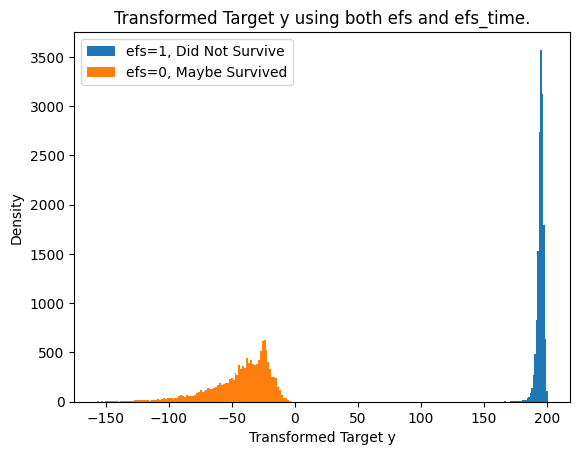

In [ ]:
M = 200

# Calculate the risk score
train['y'] = (train['efs'] * (M + 1)) - train['efs_time']

plt.hist(train.loc[train.efs==1,"y"],bins=100,label="efs=1, Did Not Survive")
plt.hist(train.loc[train.efs==0,"y"],bins=100,label="efs=0, Maybe Survived")
plt.xlabel("Transformed Target y")
plt.ylabel("Density")
plt.title("Transformed Target y using both efs and efs_time.")
plt.legend()
plt.show()

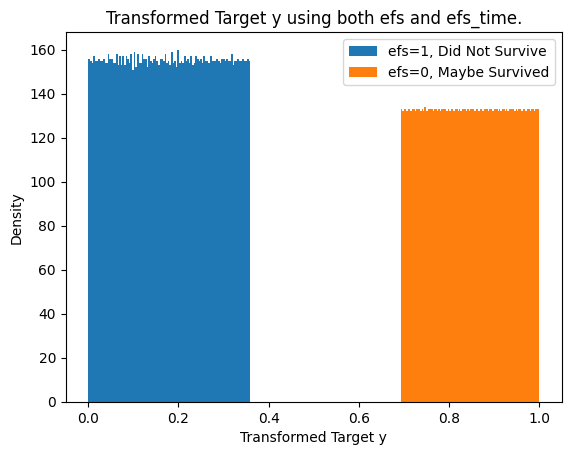

In [ ]:
# Both targets efs and efs_time provide useful information. We will tranform these two targets into a single target to train our model with.
# Taken from https://www.kaggle.com/code/wjones3668/cibmtr-equity-in-post-hct-survival-predictions

train["y"] = train.efs_time.values
mx = train.loc[train.efs==1,"efs_time"].max()
mn = train.loc[train.efs==0,"efs_time"].min()
train.loc[train.efs==0,"y"] = train.loc[train.efs==0,"y"] + mx - mn
train.y = train.y.rank()
train.loc[train.efs==0,"y"] += len(train)//2
train.y = train.y / train.y.max()



plt.hist(train.loc[train.efs==1,"y"],bins=100,label="efs=1, Did Not Survive")
plt.hist(train.loc[train.efs==0,"y"],bins=100,label="efs=0, Maybe Survived")
plt.xlabel("Transformed Target y")
plt.ylabel("Density")
plt.title("Transformed Target y using both efs and efs_time.")
plt.legend()
plt.show()

Explanation: 

### Data Preparation

In [4]:
train.columns.sort_values()

Index(['ID', 'age_at_hct', 'arrhythmia', 'cardiac', 'cmv_status',
       'comorbidity_score', 'conditioning_intensity', 'cyto_score',
       'cyto_score_detail', 'diabetes', 'donor_age', 'donor_related',
       'dri_score', 'efs', 'efs_time', 'ethnicity', 'graft_type', 'gvhd_proph',
       'hepatic_mild', 'hepatic_severe', 'hla_high_res_10', 'hla_high_res_6',
       'hla_high_res_8', 'hla_low_res_10', 'hla_low_res_6', 'hla_low_res_8',
       'hla_match_a_high', 'hla_match_a_low', 'hla_match_b_high',
       'hla_match_b_low', 'hla_match_c_high', 'hla_match_c_low',
       'hla_match_dqb1_high', 'hla_match_dqb1_low', 'hla_match_drb1_high',
       'hla_match_drb1_low', 'hla_nmdp_6', 'in_vivo_tcd', 'karnofsky_score',
       'melphalan_dose', 'mrd_hct', 'obesity', 'peptic_ulcer',
       'prim_disease_hct', 'prior_tumor', 'prod_type', 'psych_disturb',
       'pulm_moderate', 'pulm_severe', 'race_group', 'renal_issue',
       'rheum_issue', 'rituximab', 'sex_match', 'tbi_status', 'tce_div_matc

In [5]:
null_counts = train.isna().sum().sort_values(ascending=False)/len(train)

px.bar(null_counts)

In [6]:
obesity_map = {'Not done':0,
               'No':1,
               'Yes':2}

dri_score_map = {'Missing disease status': 0,
                 'N/A - pediatric': 1,
                 'N/A - disease not classifiable':1, 
                'N/A - non-malignant indication':1, 
                'TBD cytogenetics':1,
                'Low':2,
                'Intermediate':3, 
                'Intermediate - TED AML case <missing cytogenetics':4,
                'High':5, 
                'High - TED AML case <missing cytogenetics':5, 
                'Very high':6}

# Apply mappings
train['obesity'] = train['obesity'].map(obesity_map).fillna(0)
train['dri_score'] = train['dri_score'].map(dri_score_map).fillna(0)

test['obesity'] = test['obesity'].map(obesity_map).fillna(0)
test['dri_score'] = test['dri_score'].map(dri_score_map).fillna(0)

In [7]:
X_cols = ['obesity','dri_score','year_hct']

x = train[X_cols] # train.drop(columns=['efs','efs_time','y'])
y = train['y']

### Train-Test Split

During development, could use train-test split to validate model performance on some known data.

When submitting, want to train model on all of the data

In [8]:
# During Dev
# x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

# Otherwise
x_train = x
y_train = y

### Train LGB Model

In [9]:
model = lgb.LGBMRegressor(learning_rate=0.09,max_depth=-5,random_state=42)
model.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 3
[LightGBM] [Info] Start training from score 0.486910


LGBMRegressor(learning_rate=0.09, max_depth=-5, random_state=42)

### Generate Predictions

In [10]:
y_pred = model.predict(test[X_cols])

for i in sample_submission.index:
    sample_submission["prediction"].at[i] = y_pred[i]

sample_submission.head()

,ID,prediction
0,28800,0.604527
1,28801,0.445798
2,28802,0.614932


<b>END</>